In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('placement.csv')

In [4]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'Package(in lpa)')

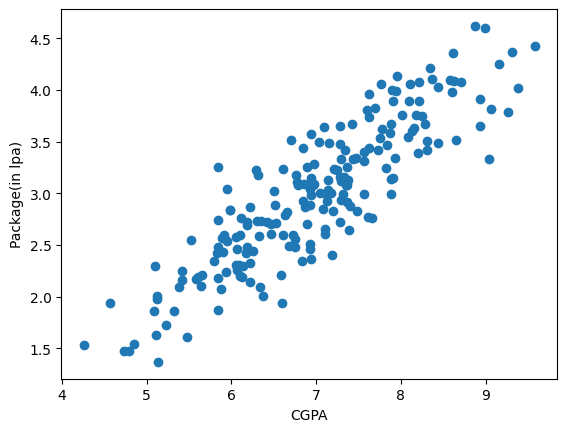

In [5]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [6]:
X = df.iloc[:,0:1]
y = df.iloc[:,-1]

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [8]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

Text(0, 0.5, 'Package(in lpa)')

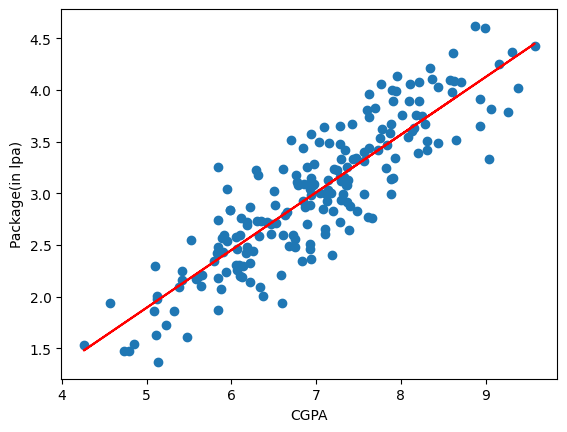

In [9]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train,lr.predict(X_train),color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [10]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [11]:
y_pred = lr.predict(X_test)

In [12]:
print("MAE: ", mean_absolute_error(y_test,y_pred))
print("MSE:", mean_squared_error(y_test,y_pred))
print("RMSE: ", np.sqrt(mean_squared_error(y_test,y_pred)))
print("R2: ", r2_score(y_test,y_pred))

MAE:  0.2884710931878175
MSE: 0.12129235313495527
RMSE:  0.34827051717731616
R2:  0.780730147510384


### Adjusted R2 score

In [13]:
r2 = r2_score(y_test,y_pred)

In [14]:
X_test.shape

(40, 1)

In [15]:
1 - ((1-r2)*(40-1)/(40-1-1))

0.7749598882343415

- Adding irrelevant feature

In [16]:
new_df1 = df.copy()
new_df1['random_feature'] = np.random.random(200)

new_df1 = new_df1[['cgpa','random_feature','package']]
new_df1.head()

,cgpa,random_feature,package
0,6.89,0.464887,3.26
1,5.12,0.662965,1.98
2,7.82,0.332544,3.25
3,7.42,0.448584,3.67
4,6.94,0.765201,3.57


Text(0, 0.5, 'Package(in lpa)')

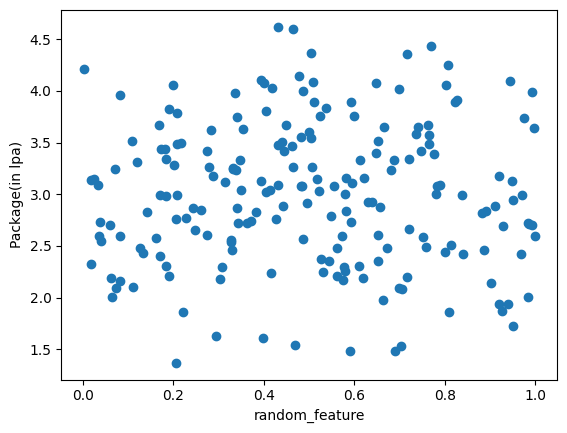

In [17]:
plt.scatter(new_df1['random_feature'],new_df1['package'])
plt.xlabel('random_feature')
plt.ylabel('Package(in lpa)')

In [18]:
X = new_df1.iloc[:,0:2]
y = new_df1.iloc[:,-1]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)


In [20]:
print("R2 score: " ,r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 score:  0.7793152906666596


In [21]:
1 - ((1-r2)*(40-1)/(40-1-2))

0.767386387459452

- Adding relevant feature

In [22]:
new_df2 = df.copy()

new_df2['iq'] = new_df2['package'] + (np.random.randint(-12,12,200)/10)
new_df2 = new_df2[['cgpa','iq','package']]

In [23]:
new_df2.sample(5)

,cgpa,iq,package
15,7.25,3.73,3.23
44,5.09,2.76,1.86
107,6.33,2.19,2.59
90,7.11,3.76,2.66
131,6.37,2.61,2.01


Text(0, 0.5, 'Package(in lpa)')

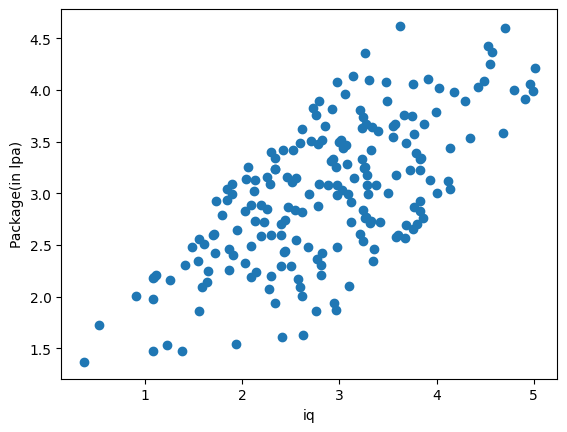

In [24]:
plt.scatter(new_df2['iq'],new_df2['package'])
plt.xlabel('iq')
plt.ylabel('Package(in lpa)')

In [25]:
X = new_df2.iloc[:,0:2]
y = new_df2.iloc[:,-1]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)

In [28]:
print("R2 score: " ,r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 score:  0.8101791589685496


In [29]:
1 - ((1-r2)*(40-1)/(40-1-2))

0.7999185729668497